In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)

# --- domínio ---
min_lambda = vp / 1e9  # comprimento de onda mínimo para 1 GHz = 3e-1 m
Nx = Ny = 50
dx = dy = 0.1 * min_lambda
dt = dx / (vp * np.sqrt(2))
Nt = 100
L = Nx * dx
T = Nt * dt

cx, cy = Nx // 2, Ny // 2

# modo TE 2D -> sempre olhe a celula de Yee no livro para ver onde cada campo é definido
grid_x_Hz = np.linspace(dx/2, L - dx/2, Nx)
grid_y_Hz = np.linspace(dy/2, L - dy/2, Ny)
grid_t_Hz = np.linspace(dt/2, T - dt/2, Nt)

grid_x_Ex = np.linspace(dx/2, L - dx/2, Nx)
grid_y_Ex = np.linspace(0, L, Ny + 1)
grid_t_Ex = np.linspace(0, T, Nt + 1)

grid_x_Ey = np.linspace(0, L, Nx + 1)
grid_y_Ey = np.linspace(dy/2, L - dy/2, Ny)
grid_t_Ey = np.linspace(0, T, Nt + 1)

# --- campos ---
Hz_curr = Hz_next = np.zeros((grid_x_Hz.shape[0], grid_y_Hz.shape[0]))
Ex_curr = Ex_next = np.zeros((grid_x_Ex.shape[0], grid_y_Ex.shape[0]))
Ey_curr = Ey_next = np.zeros((grid_x_Ey.shape[0], grid_y_Ey.shape[0]))

# ponta de prova para coletar pontos para a FFT no centro da cavidade
probe = []

# valores do tempo para salvar os snapshots e montar os heatmaps
n_snapshots = np.linspace(20, Nt - 5, 6, dtype=int)
Hz_snapshots = []

for n in range(Nt-1):
    # --- fonte (pulso gaussiano no tempo) ---
    source_gaussiano = np.exp(-((n * dt - 1.8e-9)**2) / (0.6e-9)**2)

    # --- fonte (senoidal no tempo) ---
    frequency = 30e9
    source_senoidal = np.sin(2 * np.pi * frequency * n * dt)

    Hz_curr[cx, cy] += source_gaussiano

    Ex_next[1:-1, 1:-1] = Ex_curr[1:-1, 1:-1] + (dt/(eps*dy)) * (
        Hz_curr[1:-1, 1:] - Hz_curr[1:-1, :-1]
    )

    Ey_next[1:-1, 1:-1] = Ey_curr[1:-1, 1:-1] - (dt/(eps*dx)) * (
        Hz_curr[1:, 1:-1] - Hz_curr[:-1, 1:-1]
    )

    # zero nas nas extremidades - PEC
    Ex_next[:, 0] = 0
    Ex_next[:, -1] = 0
    Ex_next[0, :] = 0
    Ex_next[-1, :] = 0

    Ey_next[:, 0] = 0
    Ey_next[:, -1] = 0
    Ey_next[0, :] = 0
    Ey_next[-1, :] = 0

    Hz_next[:, :] = Hz_curr[:, :] + (dt/mu) * (
        (Ex_next[:, 1:] - Ex_next[:, :-1]) / dx -
        (Ey_next[1:, :] - Ey_next[:-1, :]) / dy
    )

    # salva o valor no centro para a FFT
    probe.append(Hz_next[cx + 5, cy + 5])

    # atualiza os campos para o próximo passo
    Hz_curr = Hz_next.copy()
    Ex_curr = Ex_next.copy()
    Ey_curr = Ey_next.copy()

    # salva para os snapshots
    if n in n_snapshots:
        Hz_snapshots.append(Hz_curr.copy())


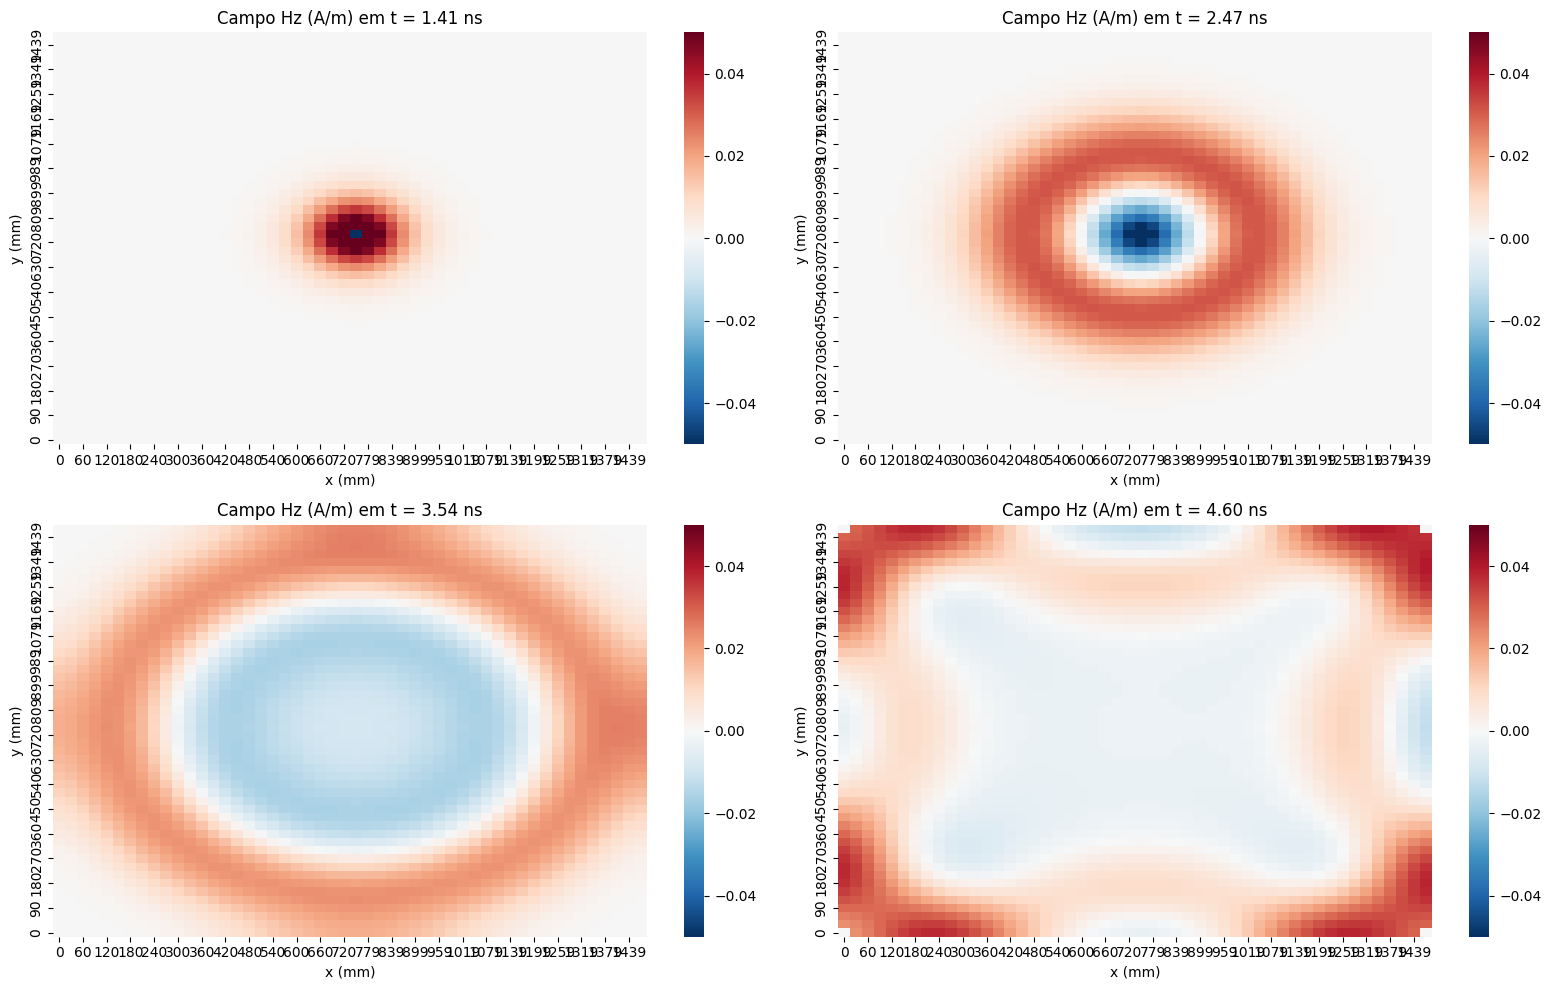

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    sns.heatmap(Hz_snapshots[i], ax=ax, annot=False, cmap='RdBu_r',vmin=-0.05, vmax=0.05,center=0)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"Campo Hz (A/m) em t = {n_snapshots[i]*dt*1e9:.2f} ns")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1000:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1000:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()